In [2]:
import numpy as np
from scipy.stats import norm, gaussian_kde
from matplotlib import pyplot as plt
import hanoi

Here I visualise the distribution of fitness of genotypes with different variances.

I consider phenotype $z$ in range (-10, 10).

In [3]:
z = np.linspace(-10, 10, 1000).reshape((1000,1))

For each of these phenotypes, I compute fitness based on a sigmoid fitness function.

In [68]:
w = hanoi.fit_sigmoid([1], [1], z)

For each phenotype value, I also compute probability density for each genotype.
Here I consider two genotypes with mean of 0 and variance of 0.5 or 2.

In [69]:
pd_0 = norm.pdf(z, 0, 0.5).flatten()

In [70]:
pd_1 = norm.pdf(z, 0, 2).flatten()

I visualise the phenotypic distribution per genotype

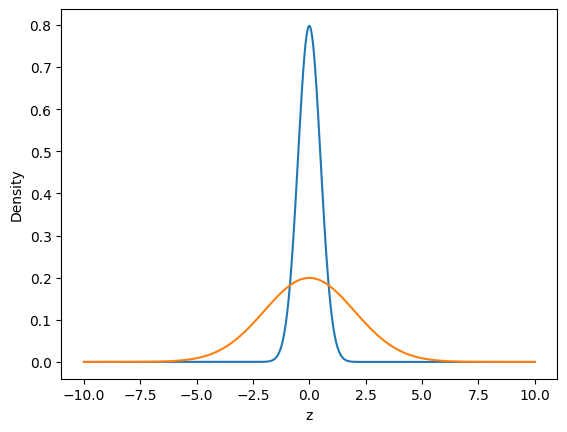

In [71]:
plt.plot(z, pd_0)
plt.plot(z, pd_1)
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

I also visualise the fitness function.

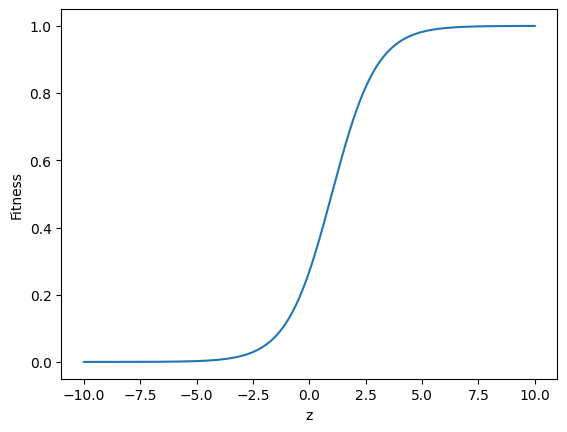

In [72]:
plt.plot(z, w)
plt.xlabel("z")
plt.ylabel("Fitness")
plt.show()

Now, I compute probability density distribution of fitness for each genotype.
This can be computed as $p_Z(z) \lvert \frac{dz}{dw} \lvert$. 

In [73]:
# numerical derivative dz/dw
dw_dz = np.gradient(w, z.flatten())  # dw/dz
dz_dw = 1 / dw_dz  # dz/dw

# fitness density
fd_0 = pd_0 * np.abs(dz_dw)
fd_1 = pd_1 * np.abs(dz_dw)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_21057/3346144617.py:1: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(w, fd_0, label="$\sigma^2=0.5$")
/tmp/ipykernel_21057/3346144617.py:2: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(w, fd_1, label='$\sigma^2=2$')


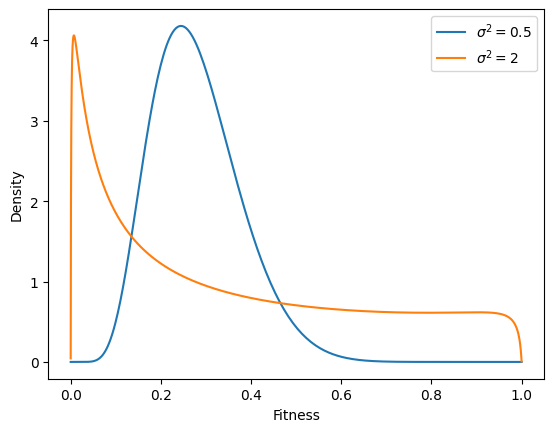

In [74]:
plt.plot(w, fd_0, label="$\sigma^2=0.5$")
plt.plot(w, fd_1, label='$\sigma^2=2$')
plt.xlabel('Fitness')
plt.ylabel('Density')
plt.legend()
plt.show()

In [75]:
z_0 = np.random.normal(0, 0.5, 10000).reshape((10000,1))
z_1 = np.random.normal(0, 2, 10000).reshape((10000,1))

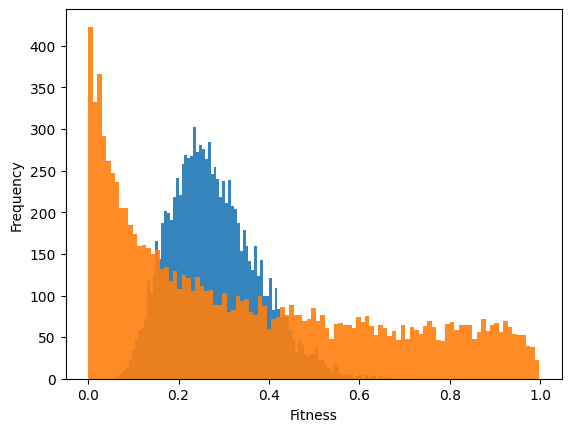

In [77]:
plt.hist(hanoi.fit_sigmoid([1], [1], z_0), bins = 101, alpha = 0.9)
plt.hist(hanoi.fit_sigmoid([1], [1], z_1), bins = 101, alpha = 0.9)
plt.xlabel("Fitness")
plt.ylabel("Frequency")
plt.show()